# AI Quant-Mate Session 5 & 6 — 데이터베이스 구축 (SQLite)

주제: **"과거의 나 vs 현재의 나"** — 매일의 주가와 AI 비평을 SQLite에 누적 저장하고, 시점 간 비교까지.

## 흐름 (총 22단계)

**Phase C — 데이터 영속화 기초**
1. DB 파일 연결
2. `tickers` 테이블 (종목 마스터)
3. PRAGMA로 스키마 확인
4. `prices` 테이블 (일별 시세) — 복합 PK
5. 시세 적재 — 누적 저장 패턴(UPSERT)
6. pandas ↔ SQLite 양방향
7. `ai_reviews` 테이블 (AI 비평 로그)

**Phase D — 분석과 비교**

8. SELECT / WHERE / ORDER BY
9. 기간 슬라이스 (BETWEEN)
10. 집계 GROUP BY
11. 과거 vs 현재 (self-join)
12. 시각화 ① 종가 추이
13. 시각화 ② 거래량 + 일별 수익률

**Phase E — 운영 안정성**

14. 트랜잭션 (`with conn:`)
15. 에러 다루기 (`IntegrityError`)
16. ALTER TABLE — 마이그레이션

**Phase F — AI 연결**

17. OpenAI 클라이언트 준비
18. AI 비평 누적
19. AI 비평 시간 추적

**Phase G — 마무리**

20. INDEX + EXPLAIN QUERY PLAN
21. JOIN 종합 리포트
22. 백업 & 다음 주(4주차) 예고

> 셀은 위에서 아래로 순서대로 실행한다. `sqlite3`는 파이썬 표준 라이브러리라 별도 설치 없이 바로 쓸 수 있다.

## Step 0 — 라이브러리 install & import

이번 주차에서 새로 들어오는 친구는 표준 라이브러리 `sqlite3` 하나뿐이다. 시각화에 `matplotlib`, AI 호출에 `openai`, 표 다루기에 `pandas`.

In [1]:
!pip install pandas matplotlib openai pykrx -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.2 MB/s eta 0:00:00


In [2]:
import sqlite3
import shutil
import os
from datetime import datetime, timedelta

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from pykrx import stock

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


---
## Step 1 — DB 파일 연결

`sqlite3.connect("quant.db")` — 파일이 없으면 자동 생성, 있으면 그냥 연다.

- `conn` : DB와의 통신 채널
- `cur`  : SQL을 실어 보낼 손잡이
- `PRAGMA foreign_keys = ON` — SQLite는 기본값이 OFF다. FK를 강제하려면 매 연결마다 켜 줘야 한다.

In [3]:
conn = sqlite3.connect("quant.db")
conn.execute("PRAGMA foreign_keys = ON")
cur = conn.cursor()

cur.execute("SELECT sqlite_version()")
print("✅ SQLite version:", cur.fetchone()[0])

✅ SQLite version: 3.37.2


---
## Step 2 — `tickers` 테이블 (종목 마스터)

종목 코드·이름·섹터처럼 **거의 변하지 않는 정보**는 별도 표에 분리한다. 이름이 바뀌어도 한 줄만 고치면 된다.

- `PRIMARY KEY (ticker)` — 같은 종목코드를 두 번 못 넣게 강제
- `INSERT OR REPLACE` — 같은 ticker가 있으면 덮어쓰기

In [4]:
cur.execute("""
    CREATE TABLE IF NOT EXISTS tickers (
        ticker TEXT PRIMARY KEY,
        name   TEXT NOT NULL,
        sector TEXT,
        market TEXT
    )
""")

ticker_rows = [
    ("005930", "삼성전자",   "반도체",       "KOSPI"),
    ("000660", "SK하이닉스", "반도체",       "KOSPI"),
    ("042700", "한미반도체", "반도체장비",   "KOSPI"),
    ("035420", "NAVER",      "인터넷",       "KOSPI"),
    ("051910", "LG화학",     "화학",         "KOSPI"),
]
cur.executemany(
    "INSERT OR REPLACE INTO tickers VALUES (?, ?, ?, ?)",
    ticker_rows,
)
conn.commit()

pd.read_sql_query("SELECT * FROM tickers", conn)

,ticker,name,sector,market
0,005930,삼성전자,반도체,KOSPI
1,000660,SK하이닉스,반도체,KOSPI
2,042700,한미반도체,반도체장비,KOSPI
3,035420,NAVER,인터넷,KOSPI
4,051910,LG화학,화학,KOSPI


---
## Step 3 — PRAGMA로 스키마 확인

DB가 실제로 어떤 컬럼을 잡고 있는지 확인하는 가장 빠른 방법은 `PRAGMA table_info(<table>)`. 디버깅의 첫 단추.

In [5]:
pd.read_sql_query("PRAGMA table_info(tickers)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,ticker,TEXT,0,None,1
1,1,name,TEXT,1,None,0
2,2,sector,TEXT,0,None,0
3,3,market,TEXT,0,None,0


---
## Step 4 — `prices` 테이블 (일별 시세)

**복합 PRIMARY KEY (ticker, date)** — "한 종목의 한 거래일은 단 한 행"이라는 규칙을 DB가 강제한다.

이 규칙 덕분에 매일 적재 스크립트가 같은 날짜를 두 번 넣어도 안전하게 만들 수 있다 (다음 단계에서 UPSERT).

In [6]:
cur.execute("""
    CREATE TABLE IF NOT EXISTS prices (
        ticker  TEXT    NOT NULL,
        date    TEXT    NOT NULL,
        open    REAL,
        high    REAL,
        low     REAL,
        close   REAL,
        volume  INTEGER,
        PRIMARY KEY (ticker, date),
        FOREIGN KEY (ticker) REFERENCES tickers(ticker)
    )
""")
conn.commit()
pd.read_sql_query("PRAGMA table_info(prices)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,ticker,TEXT,1,None,1
1,1,date,TEXT,1,None,2
2,2,open,REAL,0,None,0
3,3,high,REAL,0,None,0
4,4,low,REAL,0,None,0
5,5,close,REAL,0,None,0
6,6,volume,INTEGER,0,None,0


---
## Step 5 — 시세 적재 (실제 KRX 시세 / UPSERT)

`pykrx`로 KRX 일별 OHLCV를 받아 `prices`에 적재한다. 한국시장은 주말·공휴일이 있어 캘린더 30일 범위로 받아 약 14개 **거래일**이 들어오게 한다.

핵심은 `INSERT OR REPLACE` — 같은 (ticker, date)가 있으면 갈아끼우고 없으면 새로 넣는다. 매일 cron 스크립트가 같은 날 두 번 돌아도 안전.

> ⚠️ 이 셀은 인터넷 + KRX 응답이 필요하다. Colab에서는 그대로 동작한다. 이전에 합성 데이터로 적재했던 행은 시작 시 `DELETE`로 정리한다.

In [7]:
TODAY = datetime.today().date()
fetch_start = (TODAY - timedelta(days=30)).strftime("%Y%m%d")  # 캘린더 30일 → 약 14 거래일
fetch_end   = TODAY.strftime("%Y%m%d")

base_prices = {
    "005930": "삼성전자",
    "000660": "SK하이닉스",
    "042700": "한미반도체",
    "035420": "NAVER",
    "051910": "LG화학",
}

# 이전 합성 데이터를 정리하고 실제 시세로 다시 적재
cur.execute("DELETE FROM prices")
conn.commit()

all_rows = []
for ticker in base_prices:
    ohlcv = stock.get_market_ohlcv_by_date(fetch_start, fetch_end, ticker)
    for date, row in ohlcv.iterrows():
        all_rows.append((
            ticker,
            date.strftime("%Y-%m-%d"),
            float(row["시가"]),
            float(row["고가"]),
            float(row["저가"]),
            float(row["종가"]),
            int(row["거래량"]),
        ))

cur.executemany(
    """
    INSERT OR REPLACE INTO prices
    (ticker, date, open, high, low, close, volume)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """,
    all_rows,
)
conn.commit()

print(f"✅ pykrx로 적재된 행: {len(all_rows)}개  (기간 {fetch_start}~{fetch_end})")
pd.read_sql_query(
    "SELECT ticker, MIN(date) AS first_date, MAX(date) AS last_date, COUNT(*) AS days FROM prices GROUP BY ticker",
    conn,
)

✅ pykrx로 적재된 행: 115개  (기간 20260330~20260429)


,ticker,first_date,last_date,days
0,000660,2026-03-30,2026-04-29,23
1,005930,2026-03-30,2026-04-29,23
2,035420,2026-03-30,2026-04-29,23
3,042700,2026-03-30,2026-04-29,23
4,051910,2026-03-30,2026-04-29,23


---
## Step 6 — pandas ↔ SQLite 양방향

분석가 입장에서는 "DB에 들어간 데이터를 DataFrame으로 꺼내고, DataFrame을 그대로 DB에 박을 수 있다"는 점이 SQLite의 진짜 가치다.

- `pd.read_sql_query(sql, conn)` — DB → DataFrame
- `df.to_sql("table", conn, if_exists="append", index=False)` — DataFrame → DB

예시로 "5종목 × 14일" 시세 평균을 한 줄로 뽑아 본다.

In [8]:
df = pd.read_sql_query("SELECT * FROM prices", conn)
print("shape:", df.shape)
df.groupby("ticker")["close"].agg(["mean", "std", "min", "max"]).round(0)

shape: (115, 7)


,mean,std,min,max
ticker,,,,
000660,1071565.0,161355.0,807000.0,1300000.0
005930,205535.0,16875.0,167200.0,226000.0
035420,207978.0,8440.0,195800.0,220000.0
042700,289370.0,33988.0,251000.0,373500.0
051910,352174.0,33307.0,299000.0,407500.0


---
## Step 7 — `ai_reviews` 테이블 (AI 비평 로그)

주가는 **사실**, AI 비평은 **의견** — 성격이 다르다. 표를 분리한다.

- `id INTEGER PRIMARY KEY AUTOINCREMENT` — 자동 증가하는 고유번호
- `model`, `persona`도 컬럼으로 — "같은 데이터라도 어떤 페르소나가 어떤 답을 했는지" 추적 가능
- 비평은 **append-only** (덮어쓰지 않는다). 의견의 변화 자체가 분석 대상.

In [9]:
cur.execute("""
    CREATE TABLE IF NOT EXISTS ai_reviews (
        id      INTEGER PRIMARY KEY AUTOINCREMENT,
        ticker  TEXT    NOT NULL,
        date    TEXT    NOT NULL,
        model   TEXT,
        persona TEXT,
        score   INTEGER,
        text    TEXT,
        FOREIGN KEY (ticker) REFERENCES tickers(ticker)
    )
""")
conn.commit()
print("✅ ai_reviews 테이블 준비 완료")

✅ ai_reviews 테이블 준비 완료


---
## Step 8 — 기본 조회: SELECT / WHERE / ORDER BY

분석의 80%는 `SELECT … WHERE … ORDER BY`. 외우지 말고 익숙해진다.

Python에서 SQL을 호출할 때는 **반드시 `?` 플레이스홀더**를 쓴다 (SQL 인젝션 방어).

In [10]:
samsung_recent = pd.read_sql_query(
    """
    SELECT date, open, close, volume
    FROM prices
    WHERE ticker = ?
    ORDER BY date DESC
    LIMIT 5
    """,
    conn,
    params=("005930",),
)
samsung_recent

,date,open,close,volume
0,2026-04-29,219500.0,226000.0,20205287
1,2026-04-28,224000.0,222000.0,18444490
2,2026-04-27,220000.0,224500.0,22870374
3,2026-04-24,224000.0,219500.0,19626666
4,2026-04-23,223000.0,224500.0,34525485


---
## Step 9 — 기간 슬라이스 (BETWEEN)

ISO 날짜 문자열(`YYYY-MM-DD`)은 사전식 비교가 그대로 시간 비교가 된다. `BETWEEN`은 양 끝을 포함.

In [11]:
start = (TODAY - timedelta(days=7)).isoformat()
end   = TODAY.isoformat()

window = pd.read_sql_query(
    """
    SELECT t.name, p.date, p.close
    FROM prices p JOIN tickers t USING(ticker)
    WHERE p.date BETWEEN ? AND ?
    ORDER BY p.date ASC, t.name ASC
    """,
    conn,
    params=(start, end),
)
print(f"기간: {start} ~ {end}")
window.head(10)

기간: 2026-04-22 ~ 2026-04-29


,name,date,close
0,LG화학,2026-04-22,392000.0
1,NAVER,2026-04-22,214000.0
2,SK하이닉스,2026-04-22,1223000.0
3,삼성전자,2026-04-22,217500.0
4,한미반도체,2026-04-22,293500.0
5,LG화학,2026-04-23,391500.0
6,NAVER,2026-04-23,217500.0
7,SK하이닉스,2026-04-23,1225000.0
8,삼성전자,2026-04-23,224500.0
9,한미반도체,2026-04-23,293500.0


---
## Step 10 — 집계: GROUP BY

2주차의 `df.groupby("sector")["weight"].sum()` — SQL `GROUP BY`가 그 원형이다. 같은 패턴, 다른 문법.

In [12]:
summary = pd.read_sql_query(
    """
    SELECT
        t.name,
        t.sector,
        COUNT(*)             AS days,
        ROUND(AVG(p.close), 0) AS avg_close,
        MAX(p.high)          AS peak,
        MIN(p.low)           AS trough,
        SUM(p.volume)        AS total_volume
    FROM prices p JOIN tickers t USING(ticker)
    GROUP BY t.name, t.sector
    ORDER BY peak DESC
    """,
    conn,
)
summary

,name,sector,days,avg_close,peak,trough,total_volume
0,SK하이닉스,반도체,23,1071565.0,1328000.0,806000.0,95743221
1,LG화학,화학,23,352174.0,411500.0,297000.0,7784929
2,한미반도체,반도체장비,23,289370.0,379500.0,242500.0,21322399
3,삼성전자,반도체,23,205535.0,229500.0,167000.0,573372093
4,NAVER,인터넷,23,207978.0,227500.0,194200.0,16379683


---
## Step 11 — 과거 vs 현재 비교 (self-join)

같은 표를 두 번 부르면 **"어제의 나" vs "오늘의 나"**가 한 행에 나온다.

여기서는 "가장 최근 거래일" 종가와 "7일 전" 종가를 한 행에 묶어 수익률을 만든다.

In [13]:
compare = pd.read_sql_query(
    """
    WITH latest AS (
        SELECT ticker, MAX(date) AS d FROM prices GROUP BY ticker
    )
    SELECT
        t.name,
        now.date    AS today,
        ROUND(now.close, 0)   AS close_now,
        past.date   AS past_date,
        ROUND(past.close, 0)  AS close_7d,
        ROUND((now.close - past.close) * 100.0 / past.close, 2) AS ret_7d_pct
    FROM latest l
    JOIN prices  now  ON now.ticker = l.ticker AND now.date = l.d
    JOIN prices  past ON past.ticker = l.ticker
                     AND past.date = date(now.date, '-7 day')
    JOIN tickers t    ON t.ticker = l.ticker
    ORDER BY ret_7d_pct DESC
    """,
    conn,
)
compare

,name,today,close_now,past_date,close_7d,ret_7d_pct
0,한미반도체,2026-04-29,357500.0,2026-04-22,293500.0,21.81
1,SK하이닉스,2026-04-29,1293000.0,2026-04-22,1223000.0,5.72
2,LG화학,2026-04-29,407500.0,2026-04-22,392000.0,3.95
3,삼성전자,2026-04-29,226000.0,2026-04-22,217500.0,3.91
4,NAVER,2026-04-29,220000.0,2026-04-22,214000.0,2.80


---
## Step 12 — 시각화 ① 종가 추이

DB에 쌓인 시계열을 pandas로 받아 matplotlib으로 그린다. 첫날을 100으로 정규화해 종목별 상대 추이를 한 화면에 본다.

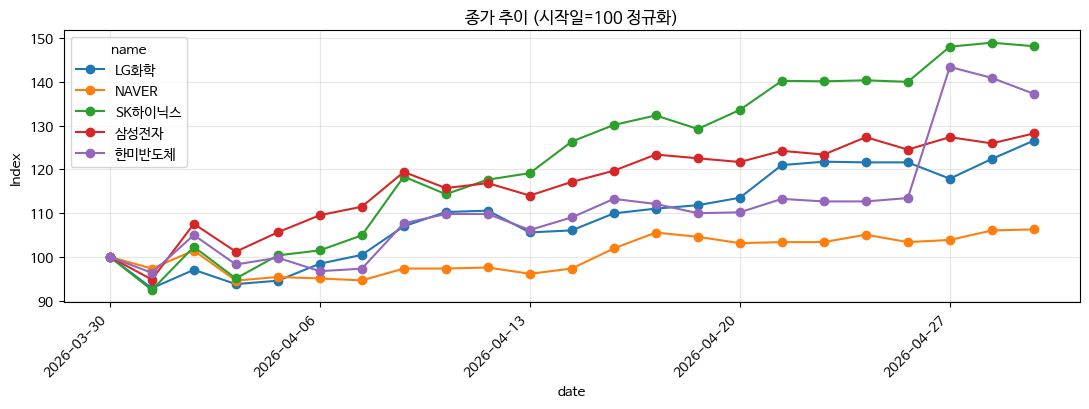

In [14]:
ts = pd.read_sql_query(
    """
    SELECT p.date, t.name, p.close
    FROM prices p JOIN tickers t USING(ticker)
    ORDER BY p.date ASC
    """,
    conn,
)
pivot = ts.pivot(index="date", columns="name", values="close")
norm = pivot / pivot.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 4.2))
norm.plot(ax=ax, marker="o")
ax.set_title("종가 추이 (시작일=100 정규화)")
ax.set_ylabel("Index")
ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Step 13 — 시각화 ② 거래량 + 일별 수익률

한 시점 차트는 정보, 여러 시점 차트는 통찰. 거래량과 일별 수익률은 변동성의 전조를 본다.

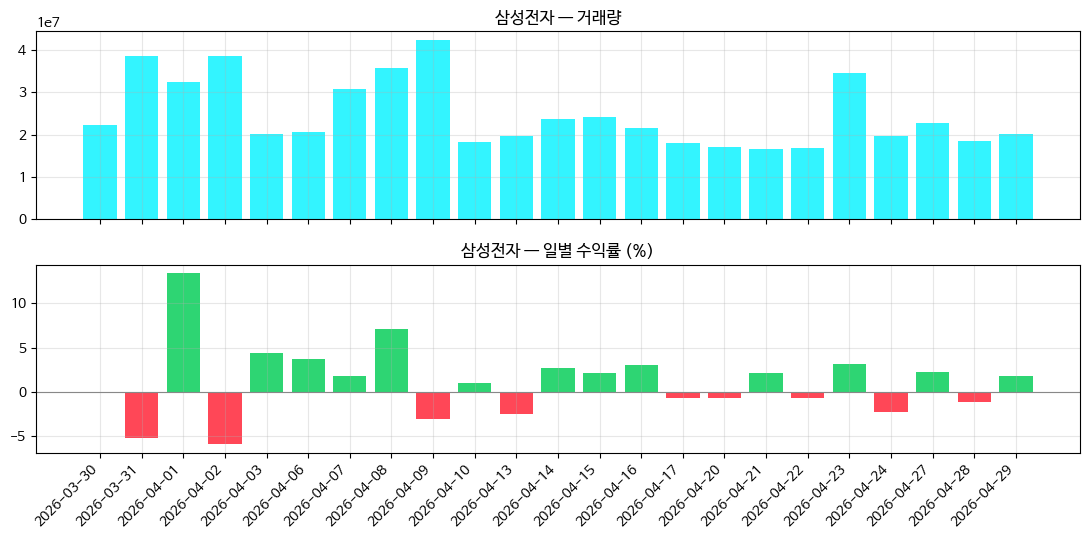

In [15]:
samsung = pd.read_sql_query(
    "SELECT date, close, volume FROM prices WHERE ticker = ? ORDER BY date ASC",
    conn,
    params=("005930",),
)
samsung["ret_pct"] = samsung["close"].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
axes[0].bar(samsung["date"], samsung["volume"], color="#00f2ff", alpha=0.8)
axes[0].set_title("삼성전자 — 거래량")
axes[0].grid(alpha=0.3)

axes[1].bar(samsung["date"], samsung["ret_pct"], color=["#2ed573" if r >= 0 else "#ff4757" for r in samsung["ret_pct"].fillna(0)])
axes[1].axhline(0, color="#888", linewidth=0.8)
axes[1].set_title("삼성전자 — 일별 수익률 (%)")
axes[1].grid(alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Step 14 — 트랜잭션 (`with conn:`)

여러 INSERT/UPDATE를 묶어 **전부 성공이거나 전부 롤백**으로 만들고 싶으면 `with conn:` 블록을 쓴다.
블록을 정상 종료하면 자동 commit, 예외가 터지면 자동 rollback.

ACID:
- **A**tomic — 중간 상태 없음
- **C**onsistent — 제약(NOT NULL, UNIQUE)이 항상 유지
- **I**solated — 동시 작업끼리 중간 상태를 안 봄
- **D**urable — commit 후엔 정전이 나도 살아남음

In [17]:
before = pd.read_sql_query("SELECT COUNT(*) AS n FROM prices", conn).iloc[0, 0]

try:
    with conn:  # 블록이 정상 종료되면 commit
        conn.execute(
            "INSERT INTO prices VALUES (?, ?, ?, ?, ?, ?, ?)",
            ("005930", "2027-01-01", 80000, 81000, 79500, 80500, 12_000_000),
        )
        # 같은 PK로 두 번째 INSERT — 충돌 발생 → 블록 전체가 롤백됨
        conn.execute(
            "INSERT INTO prices VALUES (?, ?, ?, ?, ?, ?, ?)",
            ("005930", "2027-01-01", 0, 0, 0, 0, 0),
        )
except sqlite3.IntegrityError as e:
    print(f"⚠️ 트랜잭션 롤백됨: {e}")

after = pd.read_sql_query("SELECT COUNT(*) AS n FROM prices", conn).iloc[0, 0]
print(f"행 개수: {before} → {after}  (롤백되어 변화 없음)")

⚠️ 트랜잭션 롤백됨: UNIQUE constraint failed: prices.ticker, prices.date
행 개수: 115 → 115  (롤백되어 변화 없음)


---
## Step 15 — 에러 다루기 (`IntegrityError`)

운영 적재 스크립트가 만나는 흔한 에러 3종:
1. **UNIQUE/PK 위반** — 같은 (ticker, date)를 또 넣을 때
2. **NOT NULL 위반** — 필수 컬럼이 비었을 때
3. **FOREIGN KEY 위반** — `tickers`에 없는 코드를 `prices`에 넣을 때 (PRAGMA foreign_keys=ON 일 때)

셋 다 `sqlite3.IntegrityError`로 떨어진다.

---
## Step 16 — ALTER TABLE (마이그레이션)

스키마는 영원하지 않다. "수정주가"가 필요해졌다고 하자. `ALTER TABLE … ADD COLUMN` 으로 컬럼을 새로 단다.

기존 행은 자동으로 NULL/기본값으로 채워진다. 다음 적재부터 채워 넣으면 된다.

In [20]:
existing = pd.read_sql_query("PRAGMA table_info(prices)", conn)
if "adj_close" not in existing["name"].tolist():
    cur.execute("ALTER TABLE prices ADD COLUMN adj_close REAL")
    conn.commit()
    print("✅ adj_close 컬럼 추가")
else:
    print("ℹ️ adj_close 컬럼 이미 존재")

pd.read_sql_query("PRAGMA table_info(prices)", conn)

✅ adj_close 컬럼 추가


,cid,name,type,notnull,dflt_value,pk
0,0,ticker,TEXT,1,None,1
1,1,date,TEXT,1,None,2
2,2,open,REAL,0,None,0
3,3,high,REAL,0,None,0
4,4,low,REAL,0,None,0
5,5,close,REAL,0,None,0
6,6,volume,INTEGER,0,None,0
7,7,adj_close,REAL,0,None,0


---
## Step 17 — OpenAI 클라이언트 준비

1주차에서 만든 AI 분석을 매일 돌릴 수 있도록 클라이언트만 미리 만들어 둔다.
API 키가 없으면 다음 셀에서 더미 비평으로 대체된다.

In [21]:
# --- Colab ---
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

# --- 로컬 ---
# OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

client = OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None
print("✅ client 준비" if client else "⚠️ API 키 없음 — 더미 비평으로 진행")

✅ client 준비


---
## Step 18 — AI 비평 누적

"가장 최근 거래일" 기준으로 5종목에 대해 AI 비평을 받고 `ai_reviews`에 그대로 INSERT.

API 키가 없을 때 더미 비평이 들어가는 분기를 두면 노트북이 누구의 환경에서도 끝까지 돌아간다.

In [22]:
SYSTEM_PROMPT = """
너는 월스트리트 15년차 퀀트 애널리스트다.
사용자가 준 종가 시계열을 보고 매우 짧게 비평한다.
반드시 아래 형식으로만 답하라.

📊 추세: (상승/하락/횡보 한 단어)
🎯 모멘텀 스코어: (0~100 정수 한 개)
💡 한 줄 코멘트: (40자 이내)
"""

def review_ticker(ticker: str, persona: str = "보수적 투자자") -> dict:
    series = pd.read_sql_query(
        "SELECT date, close FROM prices WHERE ticker=? ORDER BY date ASC",
        conn, params=(ticker,),
    )
    payload = series.to_dict(orient="records")
    user_prompt = f"페르소나: {persona}. 종가 시계열: {payload}. 위 형식으로만 답하라."

    if client is None:
        text = "📊 추세: 횡보\n🎯 모멘텀 스코어: 55\n💡 한 줄 코멘트: 거래량 동반 없는 반등 — 신뢰 보류"
        model = "dummy"
    else:
        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": user_prompt},
            ],
            max_tokens=120,
            temperature=0.3,
        )
        text = resp.choices[0].message.content
        model = "gpt-4o-mini"

    score = None
    for line in text.splitlines():
        if "모멘텀 스코어" in line:
            digits = "".join(ch for ch in line if ch.isdigit())
            if digits:
                score = int(digits[:3])
    return {"ticker": ticker, "persona": persona, "model": model, "score": score, "text": text}

# AI 비평은 "분석 가능한 가장 최근 거래일"을 기준으로 태깅한다.
# (캘린더 오늘이 휴장일일 수 있으므로 prices.MAX(date)를 쓴다 — Step 21 JOIN 매칭 보장.)
today_iso = pd.read_sql_query("SELECT MAX(date) AS d FROM prices", conn).iloc[0, 0]
review_rows = []
for t in base_prices:
    r = review_ticker(t)
    review_rows.append((r["ticker"], today_iso, r["model"], r["persona"], r["score"], r["text"]))

with conn:
    conn.executemany(
        """
        INSERT INTO ai_reviews (ticker, date, model, persona, score, text)
        VALUES (?, ?, ?, ?, ?, ?)
        """,
        review_rows,
    )

print(f"✅ AI 비평 {len(review_rows)}건 누적 (오늘={today_iso})")
pd.read_sql_query(
    "SELECT ticker, date, persona, score, substr(text, 1, 40) AS preview FROM ai_reviews ORDER BY id DESC LIMIT 5",
    conn,
)

✅ AI 비평 5건 누적 (오늘=2026-04-29)


,ticker,date,persona,score,preview
0,051910,2026-04-29,보수적 투자자,85,📊 추세: 상승 \n🎯 모멘텀 스코어: 85 \n💡 한 줄 코멘트: 안정
1,035420,2026-04-29,보수적 투자자,75,📊 추세: 상승 \n🎯 모멘텀 스코어: 75 \n💡 한 줄 코멘트: 안정
2,042700,2026-04-29,보수적 투자자,75,📊 추세: 상승 \n🎯 모멘텀 스코어: 75 \n💡 한 줄 코멘트: 변동
3,000660,2026-04-29,보수적 투자자,85,📊 추세: 상승 \n🎯 모멘텀 스코어: 85 \n💡 한 줄 코멘트: 안정
4,005930,2026-04-29,보수적 투자자,85,📊 추세: 상승 \n🎯 모멘텀 스코어: 85 \n💡 한 줄 코멘트: 강한


---
## Step 19 — AI 비평 시간 추적

AI는 같은 차트도 날마다, 페르소나마다 다른 답을 줄 수 있다. 그 흔들림 자체가 분석 대상이다.

여기서는 시연을 위해 "3일 전" 데이터로 한 번 더 누적해 시간축 비교가 가능한 상태를 만든다 (실전이면 그냥 매일 돌리면 된다).

In [23]:
# prices에 실제로 존재하는 날짜 중 "최근에서 3거래일 전"을 고른다
distinct_dates = pd.read_sql_query(
    "SELECT DISTINCT date FROM prices ORDER BY date DESC", conn
)["date"].tolist()
past_iso = distinct_dates[3] if len(distinct_dates) > 3 else distinct_dates[-1]

# 시뮬레이션: 3거래일 전 시점 비평을 약간 다른 스코어로 누적
past_rows = []
for t in base_prices:
    text = "📊 추세: 상승\n🎯 모멘텀 스코어: 70\n💡 한 줄 코멘트: 거래량 증가 동반 양봉"
    past_rows.append((t, past_iso, "dummy", "보수적 투자자", 70, text))

with conn:
    conn.executemany(
        "INSERT INTO ai_reviews (ticker, date, model, persona, score, text) VALUES (?, ?, ?, ?, ?, ?)",
        past_rows,
    )

print(f"✅ 과거 시점({past_iso}) AI 비평 {len(past_rows)}건 누적")
trend = pd.read_sql_query(
    """
    SELECT t.name, r.date, r.persona, r.score
    FROM ai_reviews r JOIN tickers t USING(ticker)
    ORDER BY t.name, r.date
    """,
    conn,
)
trend

✅ 과거 시점(2026-04-24) AI 비평 5건 누적


,name,date,persona,score
0,LG화학,2026-04-24,보수적 투자자,70
1,LG화학,2026-04-29,보수적 투자자,85
2,NAVER,2026-04-24,보수적 투자자,70
3,NAVER,2026-04-29,보수적 투자자,75
4,SK하이닉스,2026-04-24,보수적 투자자,70
5,SK하이닉스,2026-04-29,보수적 투자자,85
6,삼성전자,2026-04-24,보수적 투자자,70
7,삼성전자,2026-04-29,보수적 투자자,85
8,한미반도체,2026-04-24,보수적 투자자,70
9,한미반도체,2026-04-29,보수적 투자자,75


---
## Step 20 — INDEX + EXPLAIN QUERY PLAN

조회가 자주 일어나는 (ticker, date) 조합에 인덱스를 걸어 둔다.

`EXPLAIN QUERY PLAN`으로 SQLite가 인덱스를 실제로 쓰는지 확인할 수 있다 — 운영의 핵심 기술.

In [24]:
cur.execute("CREATE INDEX IF NOT EXISTS idx_prices_ticker_date  ON prices(ticker, date)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_reviews_ticker_date ON ai_reviews(ticker, date)")
conn.commit()

plan = pd.read_sql_query(
    "EXPLAIN QUERY PLAN SELECT * FROM prices WHERE ticker = '005930' ORDER BY date DESC LIMIT 5",
    conn,
)
plan

,id,parent,notused,detail
0,5,0,0,SEARCH prices USING INDEX idx_prices_ticker_da...


---
## Step 21 — JOIN 종합 리포트

세 표(`tickers`, `prices`, `ai_reviews`)를 LEFT JOIN으로 묶어 "오늘 상태" 한 화면 리포트를 만든다.

`LEFT JOIN`인 이유: 어떤 종목은 아직 AI 비평이 없을 수 있다 → 그래도 그 종목은 표에 나와야 한다.

In [25]:
report = pd.read_sql_query(
    """
    WITH latest AS (
        SELECT ticker, MAX(date) AS d FROM prices GROUP BY ticker
    )
    SELECT
        t.name,
        t.sector,
        l.d                  AS as_of,
        ROUND(p.close, 0)    AS close,
        r.score              AS ai_score,
        r.persona
    FROM latest l
    JOIN tickers t   USING(ticker)
    JOIN prices  p   ON p.ticker = l.ticker AND p.date = l.d
    LEFT JOIN ai_reviews r
           ON r.ticker = l.ticker AND r.date = l.d
    ORDER BY ai_score DESC NULLS LAST
    """,
    conn,
)
report

,name,sector,as_of,close,ai_score,persona
0,SK하이닉스,반도체,2026-04-29,1293000.0,85,보수적 투자자
1,삼성전자,반도체,2026-04-29,226000.0,85,보수적 투자자
2,LG화학,화학,2026-04-29,407500.0,85,보수적 투자자
3,NAVER,인터넷,2026-04-29,220000.0,75,보수적 투자자
4,한미반도체,반도체장비,2026-04-29,357500.0,75,보수적 투자자


---
## Step 22 — 백업 & 다음 주 예고

SQLite는 파일 한 개라 백업이 단순하다 — 그냥 복사한다. 매일 백업하면 분석 이력이 영구화된다.

**Week 4 (Session 7 & 8): "AI 스트레스 테스터"**
- MDD(최대낙폭), VaR(Value-at-Risk) 같은 하락 지표 계산
- "금리 인상 시나리오에서 내 포트는 얼마나 깨질까?"를 AI에게 묻는 로직
- 오늘 쌓은 `quant.db`를 입력으로 바로 사용한다 — 그래서 오늘 잘 쌓아야 한다.

## 핵심 메시지
1. 분석은 **스냅샷이 아니라 시계열**이다. DB가 시간을 만들어 준다.
2. **스키마는 분석의 뼈대**다. tickers / prices / ai_reviews — 성격이 다르면 표를 나눈다.
3. SQL의 **SELECT + WHERE + GROUP BY + JOIN**이 분석의 80%다.
4. DB는 **기록 도구이자 대화 도구**다 — 과거의 나에게 질문할 수 있다.

In [26]:
stamp = datetime.today().strftime("%Y%m%d")

conn.commit()
shutil.copyfile("quant.db", f"quant_backup_{stamp}.db")
report.to_csv(f"daily_report_{stamp}.csv", index=False, encoding="utf-8-sig")

print(f"✅ DB 백업: quant_backup_{stamp}.db")
print(f"✅ 일일 리포트: daily_report_{stamp}.csv")

conn.close()
print("✅ DB 연결 종료")

✅ DB 백업: quant_backup_20260429.db
✅ 일일 리포트: daily_report_20260429.csv
✅ DB 연결 종료
